## Hut Equations - Constant time lag model

### Earth and post-MS Sun
Parameters from Constant Time Lag notebook.

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

pi = np.pi

# Stellar parameters - Post-main sequence sun
solar_mass = 0.86  # solar masses
solar_radius = 0.85  # AU (expansion into a red giant)
k2_s = 0.03 # Love number

# Planetary parameters - Earth
earth_mass = 3e-6  # solar masses

G = 4*pi**2  # AU^3 / yr^2 Msun

# Initial conditions
e0 = 0.03
a0 = 1
omega_0 = 0

# Constant tidal time lag
tau = 0.04  # years

Text(0.5, 1.0, 'Hut Tidal Evolution')

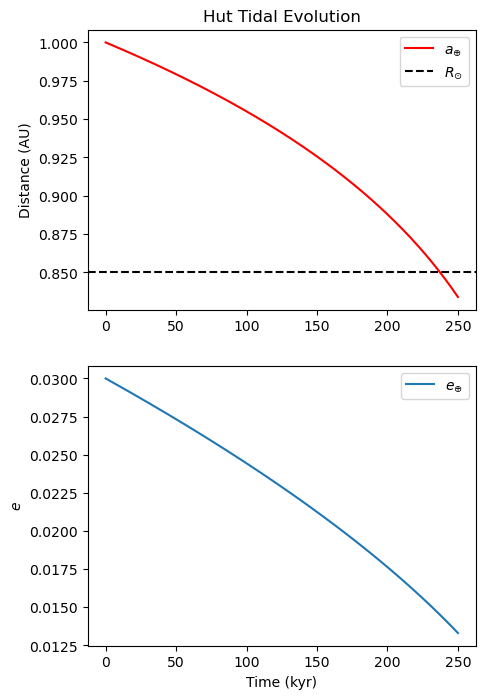

In [60]:
# Time
tmax = 2.5e5
Nout = 1000
hut_times = np.linspace(0, tmax, Nout)

# Functions
def f1_hut(e2):
    return 1 + (31/2)*e2 + (255/8)*e2**2 + (185/16)*e2**3 + (25/64)*e2**4

def f2_hut(e2):
    return 1 + (15/2)*e2 + (45/8)*e2**2 + (5/16)*e2**3

def f3_hut(e2):
    return 1 + (15/4)*e2 + (15/8)*e2**2 + (5/64)*e2**3

def f4_hut(e2):
    return 1 + (3/2)*e2 + (1/8)*e2**2

def f5_hut(e2):
    return 1 + 3*e2 + (3/8)*e2**2

def hut_model(params, t, mstar, rstar, k2star, mplanet, tau):
    a, e, omega = params
    
    k =  0.5 * k2star
    
    n = np.sqrt(G*(mstar + mplanet)/a**3)

    T = rstar**3 / (G * mstar *  2 * tau) 

    q = mplanet / mstar

    rg = 1
    
    da_dt = -6 * (k / T) * q * (1 + q) * (rstar / a)**8 * a * (1 - e**2)**(-15/2) * (
         f1_hut(e**2) - (1 - e**2)**(3/2) * f2_hut(e**2) * omega / n)

    de_dt = -27 * (k / T) * q * (1 + q) * (rstar / a)**8 * e * (1 - e**2)**(-13/2) * (
        f3_hut(e**2) - 11/18 * (1 - e**2)**(3/2) * f4_hut(e**2) * omega / n)

    domega_dt = 3 * (k / T) * (q / rg)**2 * (rstar / a)**6 * n * (1-e**2)**(-6) * (
        f2_hut(e**2) - (1 - e**2)**(3/2) * f5_hut(e**2) * omega / n)

    
    return [da_dt, de_dt, domega_dt]

initial_cond = [a0, e0, omega_0] 

hut_solution = odeint(hut_model, initial_cond, hut_times, 
                           args = (solar_mass, solar_radius, k2_s, 
                                  earth_mass, tau))

# Plotting
a_sol = hut_solution[:, 0]
e_sol = hut_solution[:, 1]

fig, ax = plt.subplots(2, 1, figsize = (5,8))

times_rescaled = hut_times / 1000

ax[0].plot(times_rescaled, a_sol, color = "r", label = r'$a_{\oplus}$')
ax[0].set_ylabel("Distance (AU)")
ax[0].axhline(y = 0.850, color = "k", linestyle = "dashed", label = r'$R_{\odot}$')
ax[0].legend()

ax[1].plot(times_rescaled, e_sol, label = r'$e_{\oplus}$')
ax[1].set_ylabel(r'$e$')
ax[1].set_xlabel("Time (kyr)")
ax[1].legend()

ax[0].set_title("Hut Tidal Evolution")

### 51 Pegasi b

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

pi = np.pi

# Stellar parameters - 51 Pegasi
fig2_r_s = 1.152 * 0.00465  # 1.152 solar radii (in AU)
fig2_m_s = 1.09  # 1.09 solar masses
k2_s = 0.03 # Love number

# Planetary parameters - 51 Pegasi b
fig2_r_p = 1.2 * 0.000477895  # 1.2 Jupiter radii (in AU)
fig2_m_p = 0.46 * 0.000954588  # 0.46 Jupiter masses (in solar masses)
k2_p = 0.3 

G = 4*pi**2

# Orbital parameters
fig2_e0 = 0.013
fig2_a0 = 0.055

# Modified tidal dissipation parameter
fig2_Qprime_s = 10**6
fig2_Qprime_p = 10**6.5
Q_s = fig2_Qprime_s * 2 * k2_s / 3
Q_p = fig2_Qprime_p * 2 * k2_p / 3


In [5]:
print(dt_s, dt_p)

4.914773010090278e-08 1.5541876894606983e-09


Text(0.5, 1.0, 'Hut Tidal Evolution')

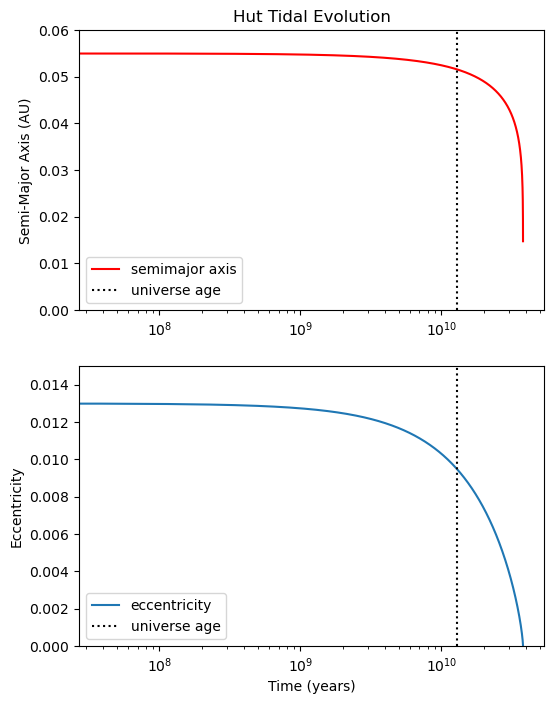

In [31]:
# Time
tmax = 3.8e10
Nout = 1000
hut_times = np.linspace(0, tmax, Nout)

# New Parameters
tau = dt_s    # using the bigger of the 2 time lag values
period = 21.9 * 0.00273973  # 1 day in years
omega_s = 2 * pi / period

# Functions
def f1_hut(e2):
    return 1 + (31/2)*e2 + (255/8)*e2**2 + (185/16)*e2**3 + (25/64)*e2**4

def f2_hut(e2):
    return 1 + (15/2)*e2 + (45/8)*e2**2 + (5/16)*e2**3

def f3_hut(e2):
    return 1 + (15/4)*e2 + (15/8)*e2**2 + (5/64)*e2**3

def f4_hut(e2):
    return 1 + (3/2)*e2 + (1/8)*e2**2

def f5_hut(e2):
    return 1 + 3*e2 + (3/8)*e2**2

def hut_model(params, t, mstar, rstar, k2star, mplanet, rplanet, k2planet):
    a, e, omega = params
    
    k = 0.5 * k2star
    
    n = np.sqrt(G*(mstar + mplanet)/a**3)

    tau = 1/(Q_s*(np.abs(2*omega - 2*n)))

    T = rstar**3 / (G * mstar * tau)

    q = mplanet / mstar

    rg = np.sqrt(2/5)
    
    da_dt = -6 * k / T * q * (1 + q) * (rstar / a)**8 * a * ((1 - e**2)**(-15/2)) * (
         f1_hut(e**2) - (1 - e**2)**(3/2) * f2_hut(e**2) * omega / n)

    de_dt = -27 * k / T * q * (1 + q) * (rstar / a)**8 * e * ((1 - e**2)**(-13/2)) * (
        f3_hut(e**2) - 11/18 * (1 - e**2)**(3/2) * f4_hut(e**2) * omega / n)

    domega_dt = 3 * k / T * q**2 / rg**2 * (rstar / a)**6 * n / ((1-e**2)**6) * (
        f2_hut(e**2) - (1 - e**2)**(3/2) * f5_hut(e**2) * omega / n)

    # domega_dt = 0
    
    return [da_dt, de_dt, domega_dt]

initial_cond = [fig2_a0, fig2_e0, omega_s] 

hut_solution = odeint(hut_model, initial_cond, hut_times, 
                           args = (fig2_m_s, fig2_r_s, k2_s, 
                                  fig2_m_p, fig2_r_p, k2_p))

# Plotting
a_sol = hut_solution[:, 0]
e_sol = hut_solution[:, 1]

fig, ax = plt.subplots(2, 1, figsize = (6,8))
ax[0].plot(hut_times, a_sol, color = "r", label = "semimajor axis")
ax[0].set_ylabel("Semi-Major Axis (AU)")
ax[0].axvline(x = 1.3e10, color = "k", linestyle = "dotted", label = "universe age")
ax[0].set_xscale("log")
ax[0].set_ylim(0,.06)
ax[0].legend()

ax[1].plot(hut_times, e_sol, label = "eccentricity")
ax[1].set_ylabel("Eccentricity")
ax[1].set_xlabel("Time (years)")
ax[1].axvline(x = 1.3e10, color = "k", linestyle = "dotted", label = "universe age")
ax[1].set_ylim(0,.015)
ax[1].legend()
ax[1].set_xscale("log")

ax[0].set_title("Hut Tidal Evolution")